## Combine all adata for study:  [Spatial fibroblast niches define Crohn’s fistulae](https://www.nature.com/articles/s41586-025-09744-y)

In [256]:
import os
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np



os.chdir("/g/stegle/aalsayah/repos/data/xenium5k/agne_cd")

### Combine all adata in ONE object

In [257]:
adata_path = Path("/g/stegle/aalsayah/repos/data/xenium5k/agne_cd/")

In [258]:
files = sorted(adata_path.glob("*.h5ad"))
adatas = [sc.read(f) for f in files]
for i, ad in enumerate(adatas, start=1):
    print(f"Processing {files[i-1].name} ({i}/{len(adatas)})")
    sc.pp.filter_cells(ad, min_genes=200)
    sc.pp.filter_genes(ad, min_cells=3)
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

Processing RUN1_SLIDE1_S2.h5ad (1/19)
Processing RUN1_SLIDE1_S3.h5ad (2/19)
Processing RUN1_SLIDE1_S5.h5ad (3/19)
Processing RUN1_SLIDE2_S4.h5ad (4/19)
Processing RUN1_SLIDE2_S5.h5ad (5/19)
Processing RUN1_SLIDE2_S6.h5ad (6/19)
Processing RUN1_SLIDE2_S7.h5ad (7/19)
Processing RUN2_SLIDE1_S1.h5ad (8/19)
Processing RUN2_SLIDE1_S2.h5ad (9/19)
Processing RUN2_SLIDE1_S5.h5ad (10/19)
Processing RUN2_SLIDE1_S6.h5ad (11/19)
Processing RUN2_SLIDE1_S8.h5ad (12/19)
Processing RUN3_SLIDE1_S1.h5ad (13/19)
Processing RUN3_SLIDE1_S2.h5ad (14/19)
Processing RUN3_SLIDE1_S3.h5ad (15/19)
Processing RUN3_SLIDE1_S4.h5ad (16/19)
Processing RUN3_SLIDE1_S5.h5ad (17/19)
Processing RUN3_SLIDE1_S6.h5ad (18/19)
Processing RUN3_SLIDE1_S7.h5ad (19/19)


In [259]:
for adata in adatas:
    adata.obsm["spatial"] = np.column_stack(
        (adata.obs["x"].values, adata.obs["y"].values)
    )

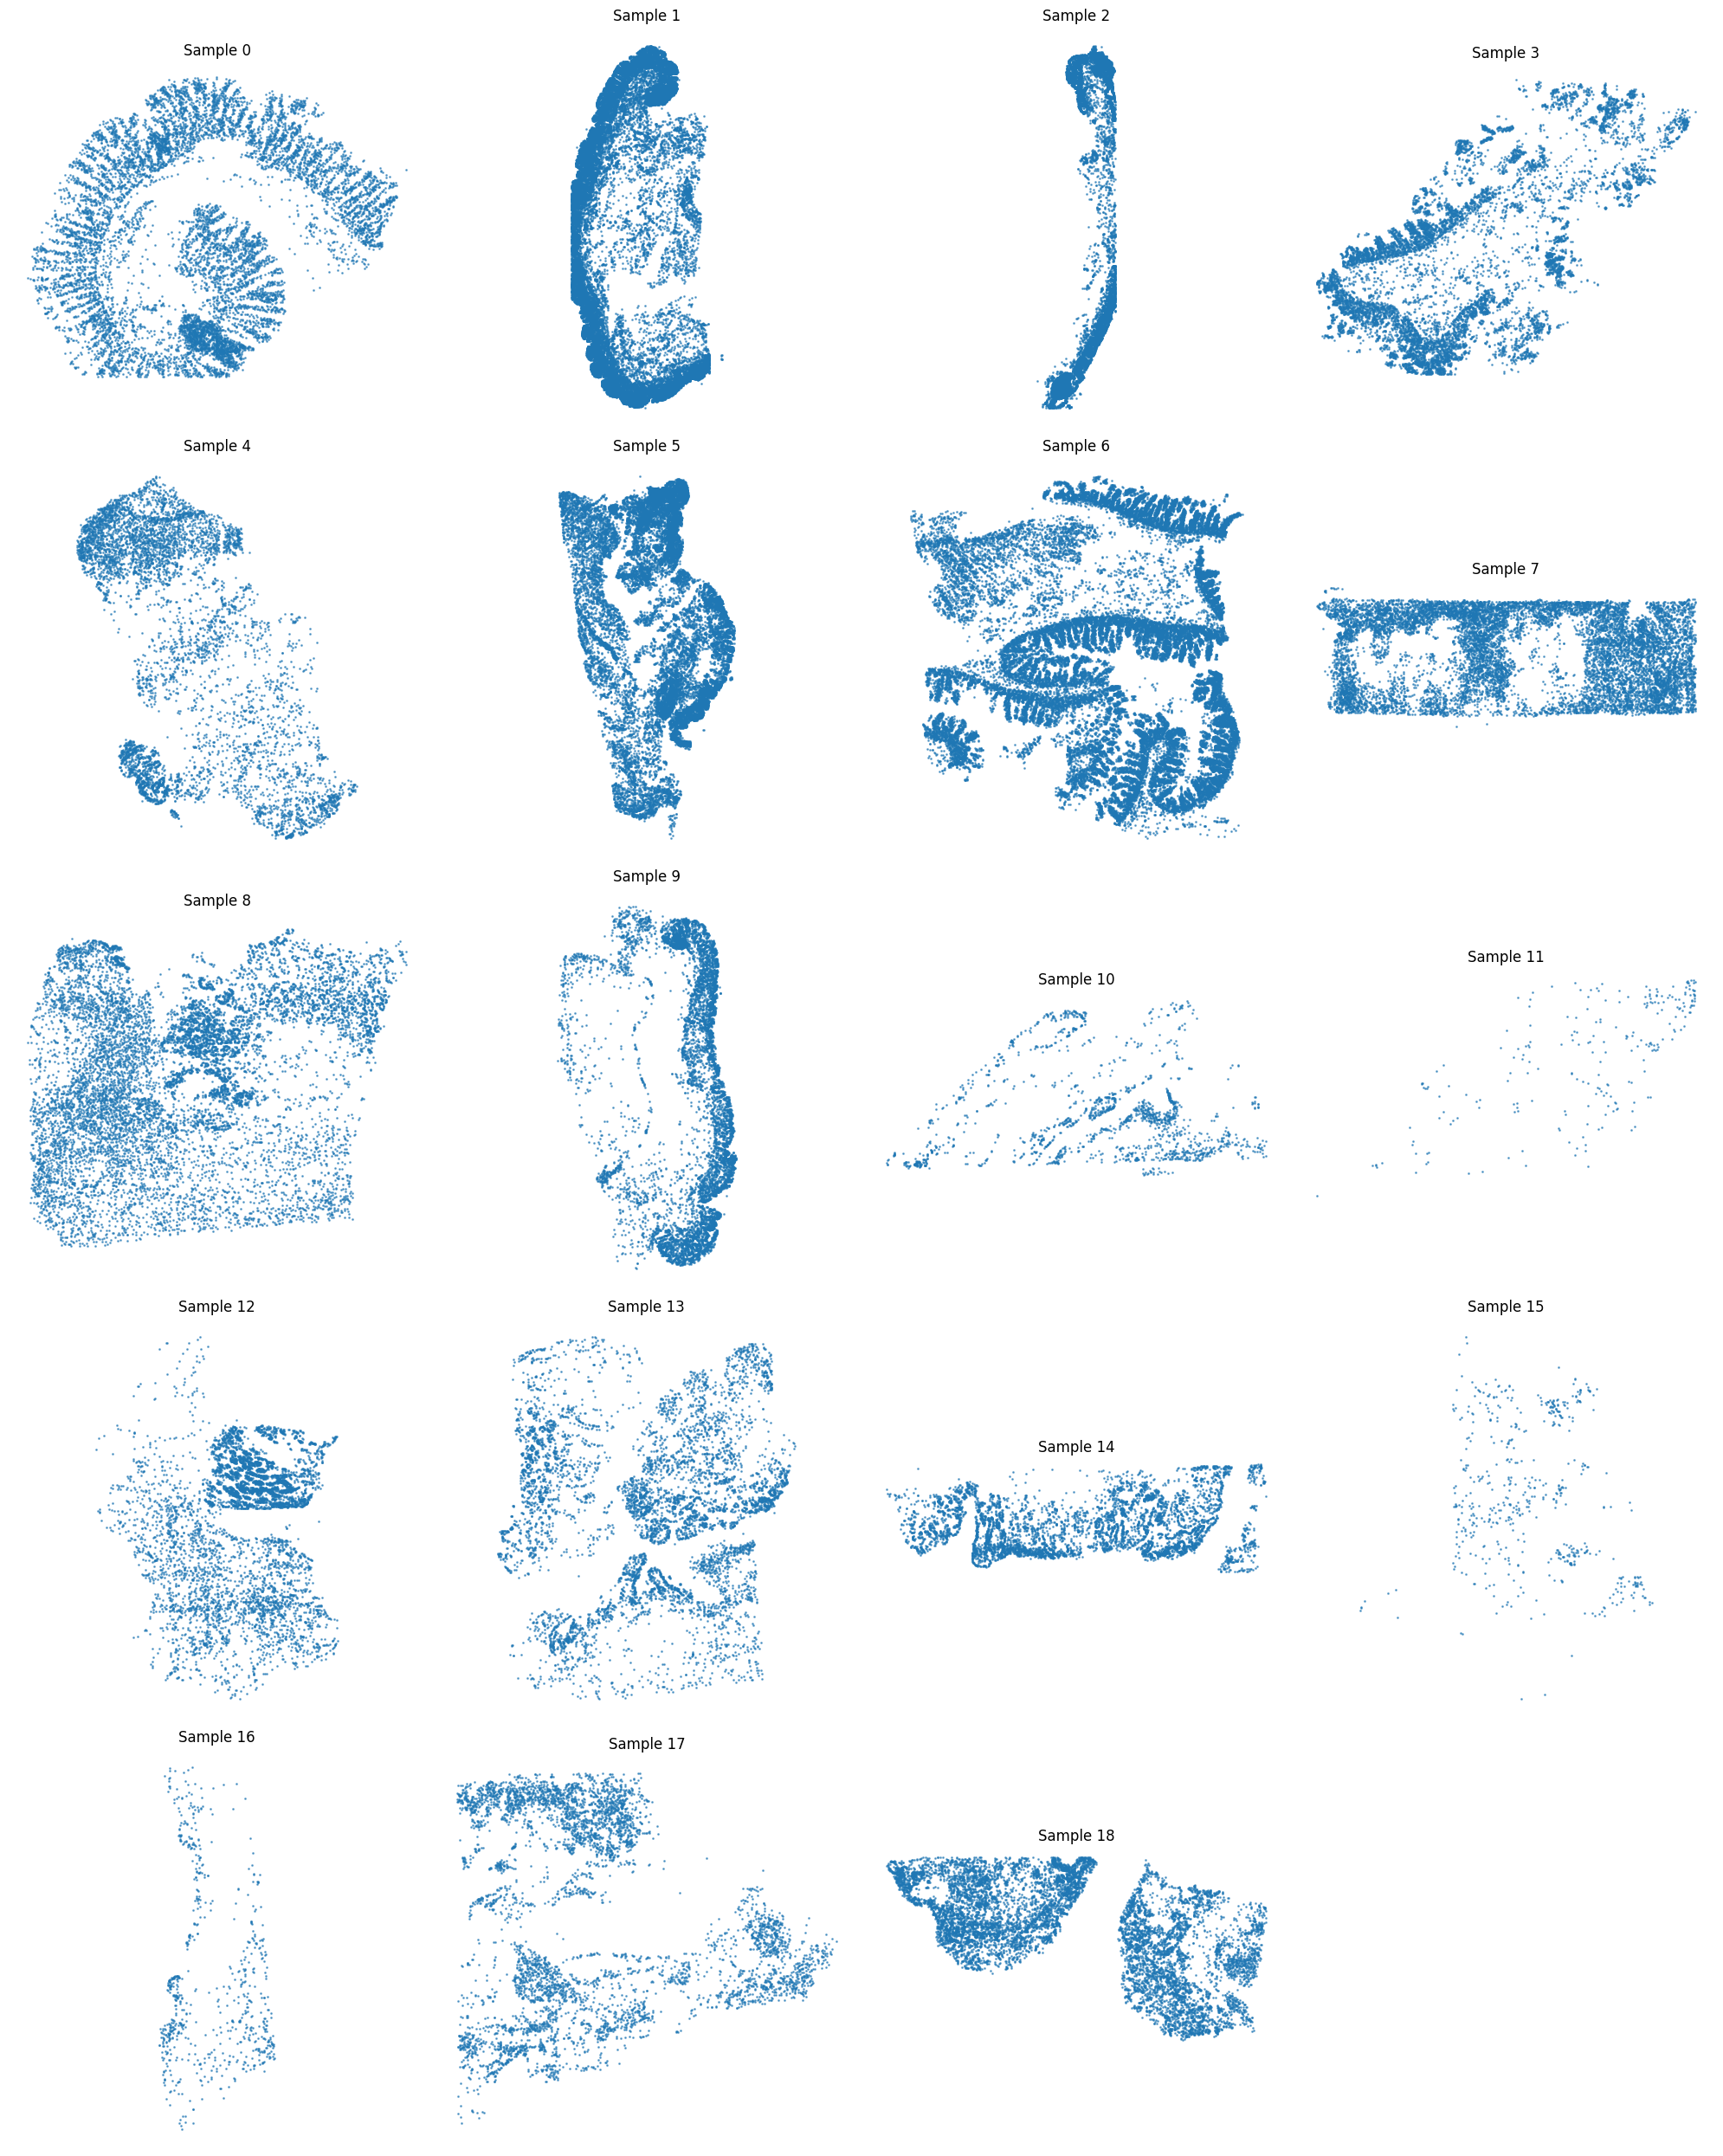

In [260]:
def arrange_in_grid(adatas, n_cols=3):
    """
    Arrange multiple spatial plots in a grid
    adatas: list of individual AnnData objects (not concatenated)
    """
    n_samples = len(adatas)
    n_rows = int(np.ceil(n_samples / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for idx, (adata, ax) in enumerate(zip(adatas, axes)):
        if 'spatial' in adata.obsm:
            coords = adata.obsm['spatial']
        else:
            coords = adata.obs[['x', 'y']].values
            
        ax.scatter(coords[:, 0], coords[:, 1], s=1, alpha=0.6)
        ax.set_title(f'Sample {idx}')
        ax.set_aspect('equal')
        ax.axis('off')
    
    # Hide empty subplots
    for idx in range(n_samples, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Use with your original list of adatas
arrange_in_grid(adatas, n_cols=4)

In [261]:
def calculate_grid_offsets(adatas, n_cols=4, margin_factor=1.2):
    """
    Calculate grid offsets to prevent overlap
    margin_factor: extra space between samples (1.2 = 20% margin)
    """
    # Get dimensions for each sample
    dimensions = []
    for adata in adatas:
        if 'spatial' in adata.obsm:
            coords = adata.obsm['spatial']
        else:
            coords = adata.obs[['x', 'y']].values
        
        # Get min and max
        x_min, x_max = coords[:, 0].min(), coords[:, 0].max()
        y_min, y_max = coords[:, 1].min(), coords[:, 1].max()
        
        width = x_max - x_min
        height = y_max - y_min
        
        dimensions.append({
            'width': width,
            'height': height,
            'x_min': x_min,
            'y_min': y_min,
            'x_range': (x_min, x_max),
            'y_range': (y_min, y_max)
        })
    
    # Calculate grid layout
    n_samples = len(adatas)
    n_rows = int(np.ceil(n_samples / n_cols))
    
    # Find max dimensions for uniform spacing
    max_width = max(d['width'] for d in dimensions)
    max_height = max(d['height'] for d in dimensions)
    
    # Calculate cell spacing with margins
    cell_width = max_width * margin_factor
    cell_height = max_height * margin_factor
    
    # Calculate offsets for each sample
    offsets = []
    for i in range(n_samples):
        row = i // n_cols
        col = i % n_cols
        
        x_offset = col * cell_width
        y_offset = row * cell_height
        
        offsets.append((x_offset, y_offset))
    
    return offsets, dimensions

# Calculate offsets
offsets, dims = calculate_grid_offsets(adatas, n_cols=4, margin_factor=1.3)

# Print offset plan
print("Grid layout plan:")
for i, (offset, dim) in enumerate(zip(offsets, dims)):
    print(f"Sample {i}: Offset = ({offset[0]:.0f}, {offset[1]:.0f}), "
          f"Size = {dim['width']:.0f} x {dim['height']:.0f}")

Grid layout plan:
Sample 0: Offset = (0, 0), Size = 3447 x 2723
Sample 1: Offset = (12642, 0), Size = 4222 x 10127
Sample 2: Offset = (25284, 0), Size = 2392 x 11049
Sample 3: Offset = (37926, 0), Size = 4746 x 3695
Sample 4: Offset = (0, 14363), Size = 4433 x 5739
Sample 5: Offset = (12642, 14363), Size = 4589 x 9458
Sample 6: Offset = (25284, 14363), Size = 6433 x 7015
Sample 7: Offset = (37926, 14363), Size = 9233 x 3369
Sample 8: Offset = (0, 28727), Size = 5561 x 4655
Sample 9: Offset = (12642, 28727), Size = 3656 x 7412
Sample 10: Offset = (25284, 28727), Size = 8294 x 3816
Sample 11: Offset = (37926, 28727), Size = 5097 x 2898
Sample 12: Offset = (0, 43090), Size = 5050 x 7581
Sample 13: Offset = (12642, 43090), Size = 5617 x 6842
Sample 14: Offset = (25284, 43090), Size = 9725 x 2762
Sample 15: Offset = (37926, 43090), Size = 6222 x 7713
Sample 16: Offset = (0, 57454), Size = 2675 x 8370
Sample 17: Offset = (12642, 57454), Size = 4603 x 4250
Sample 18: Offset = (25284, 57454), 

In [262]:
def apply_offsets_to_adatas(adatas, offsets):
    """
    Apply calculated offsets to each AnnData object
    Returns new list of adatas with adjusted coordinates
    """
    adjusted_adatas = []
    
    for i, (adata, offset) in enumerate(zip(adatas, offsets)):
        # Create a copy to avoid modifying original
        adata_adj = adata.copy()
        
        # Get original coordinates
        if 'spatial' in adata_adj.obsm:
            coords = adata_adj.obsm['spatial'].copy()
        else:
            coords = adata_adj.obs[['x', 'y']].values
        
        # Apply offset: center the sample in its grid cell
        x_min, x_max = coords[:, 0].min(), coords[:, 0].max()
        y_min, y_max = coords[:, 1].min(), coords[:, 1].max()
        
        width = x_max - x_min
        height = y_max - y_min
        
        # Calculate centering offset
        center_x_offset = offset[0] - x_min
        center_y_offset = offset[1] - y_min
        
        # Apply transformation
        coords[:, 0] += center_x_offset
        coords[:, 1] += center_y_offset
        
        # Update the AnnData object
        adata_adj.obsm['spatial'] = coords
        adata_adj.obs['x'] = coords[:, 0]
        adata_adj.obs['y'] = coords[:, 1]
        
        # Store original coordinates for reference
        adata_adj.obs['x_original'] = adata.obs['x'].copy()
        adata_adj.obs['y_original'] = adata.obs['y'].copy()
        
        adjusted_adatas.append(adata_adj)
    
    return adjusted_adatas

# Apply offsets
adjusted_adatas = apply_offsets_to_adatas(adatas, offsets)

In [237]:
def calculate_smart_offsets(adatas, grid_size=40000, n_cols=5):
    """
    More efficient packing algorithm
    """
    # Sort by height (tallest first for better packing)
    dimensions = []
    for i, adata in enumerate(adatas):
        if 'spatial' in adata.obsm:
            coords = adata.obsm['spatial']
        else:
            coords = adata.obs[['x', 'y']].values
        
        width = coords[:, 0].max() - coords[:, 0].min()
        height = coords[:, 1].max() - coords[:, 1].min()
        
        dimensions.append({
            'idx': i,
            'width': width,
            'height': height,
            'area': width * height
        })
    
    # Sort by height (descending)
    dimensions.sort(key=lambda x: x['height'], reverse=True)
    
    # Calculate positions using shelf algorithm
    positions = []
    current_x = 0
    current_y = 0
    row_height = 0
    row_items = 0
    
    for dim in dimensions:
        if current_x + dim['width'] > grid_size and row_items > 0:
            # Move to next row
            current_x = 0
            current_y += row_height * 1.1  # Add 10% margin
            row_height = 0
            row_items = 0
        
        positions.append({
            'idx': dim['idx'],
            'x': current_x,
            'y': current_y
        })
        
        current_x += dim['width'] * 1.1  # Add 10% margin
        row_height = max(row_height, dim['height'])
        row_items += 1
    
    # Sort back to original order and create offsets
    positions.sort(key=lambda x: x['idx'])
    offsets = [(p['x'], p['y']) for p in positions]
    
    return offsets

# Use smart packing
smart_offsets = calculate_smart_offsets(adatas)
adjusted_adatas_smart = apply_offsets_to_adatas(adatas, smart_offsets)

In [263]:
# First prepare each adata with sample ID
for i, adata in enumerate(adjusted_adatas):  # Use adjusted_adatas or adjusted_adatas_smart
    # Store original sample name
    if 'SAMPLE' in adata.obs.columns:
        adata.obs["sampleID"] = adata.obs["SAMPLE"].copy()
    else:
        adata.obs["sampleID"] = f"Sample_{i}"
    
    # Make cell names unique
    adata.obs_names = [f"sample{i}_{name}" for name in adata.obs_names]

# Now combine using your method
adata_combined = adjusted_adatas[0].concatenate(
    *adjusted_adatas[1:], 
    batch_key="SAMPLE",
    batch_categories=[f"SAMPLE_{i+1}" for i in range(len(adjusted_adatas))]
)

# Verify the combination
print(f"Combined shape: {adata_combined.shape}")
print(f"Number of samples: {adata_combined.obs['SAMPLE'].nunique()}")
print(f"Spatial coords shape: {adata_combined.obsm['spatial'].shape}")

# Verify no overlap by checking coordinate ranges per sample
for sample in adata_combined.obs['SAMPLE'].unique():
    mask = adata_combined.obs['SAMPLE'] == sample
    coords = adata_combined[mask].obsm['spatial']
    x_min, x_max = coords[:, 0].min(), coords[:, 0].max()
    y_min, y_max = coords[:, 1].min(), coords[:, 1].max()
    print(f"{sample}: X ({x_min:.0f}, {x_max:.0f}), Y ({y_min:.0f}, {y_max:.0f})")

/scratch/jobs/45615328/ipykernel_3934689/3690624926.py:13: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_combined = adjusted_adatas[0].concatenate(


Combined shape: (201774, 2984)
Number of samples: 19
Spatial coords shape: (201774, 2)
SAMPLE_1: X (0, 3447), Y (0, 2723)
SAMPLE_2: X (12642, 16864), Y (0, 10127)
SAMPLE_3: X (25284, 27676), Y (0, 11049)
SAMPLE_4: X (37926, 42672), Y (0, 3695)
SAMPLE_5: X (0, 4433), Y (14363, 20102)
SAMPLE_6: X (12642, 17231), Y (14363, 23821)
SAMPLE_7: X (25284, 31717), Y (14363, 21378)
SAMPLE_8: X (37926, 47159), Y (14363, 17733)
SAMPLE_9: X (0, 5561), Y (28727, 33382)
SAMPLE_10: X (12642, 16298), Y (28727, 36139)
SAMPLE_11: X (25284, 33578), Y (28727, 32542)
SAMPLE_12: X (37926, 43023), Y (28727, 31625)
SAMPLE_13: X (0, 5050), Y (43090, 50672)
SAMPLE_14: X (12642, 18259), Y (43090, 49933)
SAMPLE_15: X (25284, 35009), Y (43090, 45852)
SAMPLE_16: X (37926, 44149), Y (43090, 50803)
SAMPLE_17: X (0, 2675), Y (57454, 65823)
SAMPLE_18: X (12642, 17245), Y (57454, 61704)
SAMPLE_19: X (25284, 31802), Y (57454, 60601)


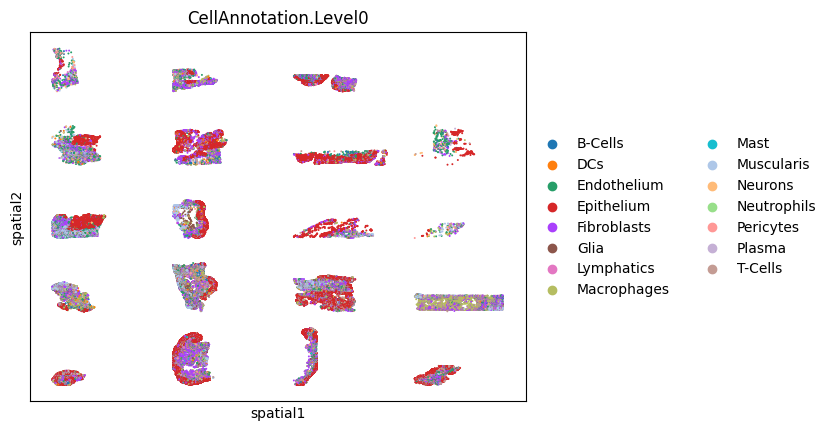

In [265]:
sc.pl.embedding(adata_combined, basis="spatial", color="CellAnnotation.Level0", size=8)

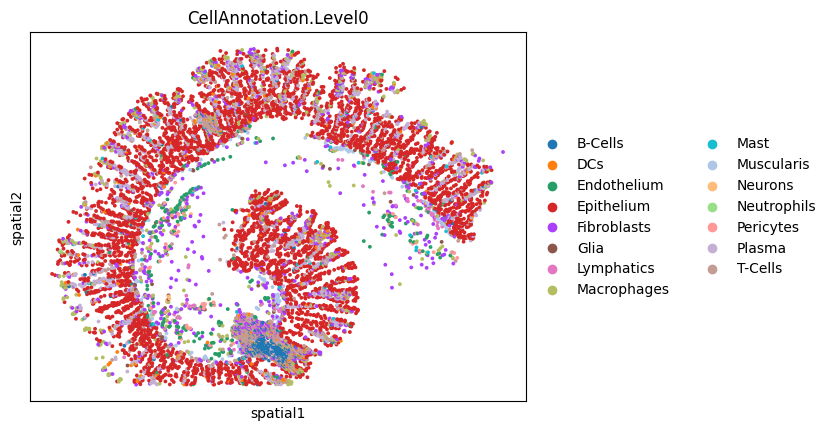

In [266]:
adata_combined_S = adata_combined[adata_combined.obs["sampleID"] == "RUN1_SLIDE1_S2"]
sc.pl.embedding(adata_combined_S, basis="spatial", color="CellAnnotation.Level0", size=30)

In [267]:
adata_combined.write_h5ad("combined_adata.h5ad")